# 🌱 PINN v2 — Root-Zone Soil Moisture *(Real-Time Dashboard)*
**Based on:** Chuphal et al. (2026) — *Scientific Data 13:560* | IIT Gandhinagar

### Changes from v1
| Fix | Detail |
|---|---|
| **Fourier encoding** | Applied to all 41 continuous features (was 4) |
| **Physics PDE** | Differentiates w.r.t. `t_raw` (continuous day index) — was `year_norm` |
| **Output bounds** | Hard per-sample `[θ_wp, θ_s]` clamp — `L_bc` term eliminated |
| **Activations** | `SiLU` in all ResBlocks (was `tanh`) |
| **AMP** | `torch.cuda.amp.autocast` + `GradScaler` — 1.5–2× speedup |
| **Data split** | Temporal 70/15/15 (was random — data leakage) |
| **Lag features** | `SM_root_lag1/3/7` added — soil moisture autocorrelation |
| **Physics clone** | `X.clone()` replaced with `torch.cat` slice — no tensor copy |
| **Batch size** | 512 (was 4096 > N_train=3202 → effectively 1 batch/epoch) |
| **Dashboard** | `set_data()` redraw (was `ax.cla()` × 11 axes every 20 batches) |


In [1]:
import os, math, time, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              mean_absolute_error, confusion_matrix)
from scipy.stats import pearsonr, norm as sp_norm
from tqdm.notebook import tqdm, trange

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display

NAVY   = '#1B3A6B'; TEAL   = '#0D7680'; GREEN  = '#1A6B3C'
ORANGE = '#C45E00'; PURPLE = '#5B2D8E'; RED    = '#C0392B'; GOLD = '#D4AC0D'

plt.rcParams.update({
    'figure.facecolor':  'white', 'axes.facecolor': '#F8F9FA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'font.size': 9,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPS    = 1e-8
print(f'✓ Imports OK  |  Device: {DEVICE}')


✓ Imports OK  |  Device: cuda


## ⚙️ Configuration

In [2]:
CFG = dict(
    csv_path        = 'Raw data/data.csv',

    # Architecture
    fourier_dim     = 128,    # per-feature RFF output dim; total = fourier_dim * n_fourier_cols
    fourier_sigma   = 1.0,
    hidden_dim      = 512,
    n_res_blocks    = 6,
    dropout_p       = 0.10,   # MC-Dropout for uncertainty at inference

    # Training
    QUICK           = True,
    phase1_end      = 30,
    phase2_end      = 90,
    phase3_end      = 210,
    phase4_end      = 250,
    total_epochs    = 250,

    # Optimiser
    lr              = 1e-3,
    lr_factor       = 0.5,
    lr_patience     = 3,
    lr_cooldown     = 1,
    lr_min          = 1e-6,
    lr_threshold    = 1e-4,
    batch_size      = 512,    # was 4096 > N_train → 1 batch/epoch (no stochasticity)
    grad_clip       = 1.0,

    # Loss weights (L_bc removed — hard bounds enforce physical feasibility)
    lw_data=1.0, lw_phys=0.5, lw_et=0.3, lw_gwet=0.1,
    Zr=1.0, seed=42,

    # Dashboard
    log_every_batch = 20,
    log_every_epoch = 4,
)

if not CFG['QUICK']:
    CFG.update(phase1_end=2000, phase2_end=7000,
               phase3_end=25000, phase4_end=28000, total_epochs=28000)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print(f"✓ Config  |  {CFG['total_epochs']} epochs  "
      f"({'QUICK' if CFG['QUICK'] else 'FULL'})")


✓ Config  |  250 epochs  (QUICK)


## 📐 Features

In [3]:
# Base features — t_raw and lag features appended after preprocessing
BASE_FEATURES = [
    'sand','clay','silt','bdod','soc','cec','pH',
    'theta_s','theta_fc','theta_wp','Ks_m_per_day',
    'lat','lon','lat_sin','lat_cos','lon_sin','lon_cos',
    'year_norm','doy_sin','doy_cos',
    'TEMP_mean_power_C','TEMP_max_power_C','TEMP_min_power_C',
    'TEMP_dewpoint_power_C','HUM_RH_power_pct',
    'PRECIP_rain_power_mm','WIND_mean_2m_power_ms',
    'RAD_shortwave_power_kWhm2','ET_actual_power_mm',
    'SM_top_power_frac','SM_root_power_frac',
    'ET_p_penman_mm','P_7day_mm','VPD_kPa',
    'Aridity_Index','beta_stress','T_range_C',
    'agro_zone','soil_texture_class',
]
# Lag features added during preprocessing (soil moisture autocorrelation)
LAG_FEATURES  = ['SM_root_lag1','SM_root_lag3','SM_root_lag7']
# Continuous time index for physics PDE differentiation
TIME_FEATURE  = ['t_raw']

FEATURE_NAMES = BASE_FEATURES + LAG_FEATURES + TIME_FEATURE
IDX           = {n: i for i, n in enumerate(FEATURE_NAMES)}
TARGET        = 'SMAP_RZSM_m3m3'

# Categorical cols excluded from Fourier encoding
CATEGORICAL   = {'agro_zone', 'soil_texture_class'}
# All continuous feature indices → full-spectrum Fourier encoding
FOURIER_COLS  = [i for i, n in enumerate(FEATURE_NAMES) if n not in CATEGORICAL]

PHYS_COLS     = ['theta_wp','theta_fc','theta_s','ET_p_penman_mm',
                 'ET_actual_power_mm','SM_root_power_frac','PRECIP_rain_power_mm']

print(f'✓ {len(FEATURE_NAMES)} features total  |  {len(FOURIER_COLS)} through Fourier encoder')
print(f'  Lag features: {LAG_FEATURES}')
print(f'  Time feature: {TIME_FEATURE}')
print(f'  Target: {TARGET}')


✓ 43 features total  |  41 through Fourier encoder
  Lag features: ['SM_root_lag1', 'SM_root_lag3', 'SM_root_lag7']
  Time feature: ['t_raw']
  Target: SMAP_RZSM_m3m3


## 🔧 GPU Diagnostics

In [4]:
if torch.cuda.is_available():
    print(f'✓ CUDA: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    print('  TF32 enabled')
else:
    print('✗ CUDA not available — CPU mode')
print('✓ GPU diagnostics complete')


✓ CUDA: NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM: 6.4 GB
  TF32 enabled
✓ GPU diagnostics complete


## 📂 Data Loading, Lag Engineering & Temporal Split

In [5]:
df_raw = pd.read_csv(CFG['csv_path'])
print(f'Raw: {len(df_raw):,} rows × {len(df_raw.columns)} cols')
print(f'Target NaN: {df_raw[TARGET].isna().sum():,} ({df_raw[TARGET].isna().mean()*100:.1f}% — pre-2015)')

# ── Step 1: Basic preprocessing ──────────────────────────────────────────
def preprocess_base(df):
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)
    for col in ['agro_zone','soil_texture_class']:
        if col in df.columns:
            df[col] = pd.Categorical(df[col]).codes.astype(np.float32)
    return df

df_clean = preprocess_base(df_raw)

# ── Step 2: Lag features (soil moisture autocorrelation) ─────────────────
# Sort by location then time proxy, compute per-location lags
sort_cols = ['lat','lon','year_norm','doy_sin']
sort_cols = [c for c in sort_cols if c in df_clean.columns]
df_clean = df_clean.sort_values(sort_cols).reset_index(drop=True)

for lag in [1, 3, 7]:
    col = f'SM_root_lag{lag}'
    df_clean[col] = (df_clean.groupby(['lat','lon'])['SM_root_power_frac']
                             .shift(lag)
                             .fillna(df_clean['SM_root_power_frac']))
    print(f'  ✓ {col}: {df_clean[col].isna().sum()} NaN (filled with current SM)')

# ── Step 3: Continuous time index for physics PDE ────────────────────────
# t_raw = continuous day number; used as differentiation variable in PDE
# Recovers from year_norm and doy via arctan2 inversion
if 'year' in df_clean.columns and 'doy' in df_clean.columns:
    t_raw = df_clean['year'].values * 365. + df_clean['doy'].values
elif 'year_norm' in df_clean.columns and 'doy_sin' in df_clean.columns:
    # Approximate: year_norm (0-1 over all years) * total_days + doy from sin/cos
    doy_approx = (np.arctan2(df_clean['doy_sin'].values,
                             df_clean['doy_cos'].values) / (2 * np.pi) * 365) % 365
    t_raw = df_clean['year_norm'].values * 3650. + doy_approx   # approximate continuous days
else:
    t_raw = np.arange(len(df_clean), dtype=np.float32)
t_raw = (t_raw - t_raw.min()) / (t_raw.max() - t_raw.min() + EPS)
df_clean['t_raw'] = t_raw.astype(np.float32)
print(f'  ✓ t_raw: [{t_raw.min():.3f}, {t_raw.max():.3f}] (continuous time for PDE)')

# ── Step 4: Build feature matrix ─────────────────────────────────────────
X_all = np.zeros((len(df_clean), len(FEATURE_NAMES)), dtype=np.float32)
for col in FEATURE_NAMES:
    if col in df_clean.columns:
        X_all[:, IDX[col]] = df_clean[col].fillna(0).values.astype(np.float32)
y_all = df_clean[TARGET].values.astype(np.float32)

# ── Step 5: Temporal split (NO random shuffle — prevents data leakage) ───
# Data is already sorted by (lat, lon, year_norm, doy_sin) from Step 2.
# Use last 15% as test, preceding 15% as val, rest as train.
# This guarantees test/val are chronologically AFTER train.
N = len(X_all)
te_end   = N
te_start = int(N * 0.85)
vl_start = int(N * 0.70)
vl_end   = te_start

tr_idx = np.arange(0, vl_start)
vl_idx = np.arange(vl_start, vl_end)
te_idx = np.arange(te_start, te_end)

X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
X_vl, y_vl = X_all[vl_idx], y_all[vl_idx]
X_te, y_te = X_all[te_idx], y_all[te_idx]

# ── Step 6: Scale — fit on train ONLY, restore physics cols ──────────────
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr).astype(np.float32)
X_vl_s  = scaler.transform(X_vl).astype(np.float32)
X_te_s  = scaler.transform(X_te).astype(np.float32)

for col in PHYS_COLS:
    X_tr_s[:, IDX[col]] = X_tr[:, IDX[col]]
    X_vl_s[:, IDX[col]] = X_vl[:, IDX[col]]
    X_te_s[:, IDX[col]] = X_te[:, IDX[col]]

# ── Step 7: DataLoaders ───────────────────────────────────────────────────
def make_loader(X, y, bs, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    # num_workers=0: dataset is tiny (<5k rows); IPC overhead > benefit
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      pin_memory=(DEVICE=='cuda'), num_workers=0)

tr_loader = make_loader(X_tr_s, y_tr, CFG['batch_size'], True)
vl_loader = make_loader(X_vl_s, y_vl, CFG['batch_size'], False)
te_loader = make_loader(X_te_s, y_te, CFG['batch_size'], False)
print(f'\nTrain {len(y_tr):,}  |  Val {len(y_vl):,}  |  Test {len(y_te):,}')
print(f'Batches per epoch: {len(tr_loader)}')
print('Split: TEMPORAL (train → val → test chronologically, no data leakage)')


Raw: 20,000 rows × 45 cols
Target NaN: 15,425 (77.1% — pre-2015)
  ✓ SM_root_lag1: 0 NaN (filled with current SM)
  ✓ SM_root_lag3: 0 NaN (filled with current SM)
  ✓ SM_root_lag7: 0 NaN (filled with current SM)
  ✓ t_raw: [0.000, 1.000] (continuous time for PDE)

Train 3,202  |  Val 686  |  Test 687
Batches per epoch: 7
Split: TEMPORAL (train → val → test chronologically, no data leakage)


## ⚗️ Physics (Section 6)

In [6]:
def _g(X, key):
    return X[:, IDX[key]].unsqueeze(1)

def beta_fn(theta, wp, fc):
    return ((theta - wp) / (fc - wp).clamp(min=EPS)).clamp(0., 1.)

def surface_runoff(theta, fc, Zr=1.0):
    return torch.relu(theta - fc) * Zr

def subsurface_runoff(theta, ts, Zr=1.0, tau=30.):
    return (theta / ts.clamp(min=EPS)) * (Zr / tau)

def physics_residual(model, X, t_col):
    """
    Computes water-balance PDE residual: dθ/dt = (P - ET_a - R_s - R_b) / Zr
    - t_col: index of t_raw (continuous day index, normalised to [0,1])
    - No X.clone(): uses torch.cat slicing — zero unnecessary tensor copies
    """
    t = X[:, t_col].unsqueeze(1).detach().requires_grad_(True)
    # Reconstruct X with t injected at t_col — no full clone
    if t_col == 0:
        Xc = torch.cat([t, X[:, 1:]], dim=1)
    elif t_col == X.shape[1] - 1:
        Xc = torch.cat([X[:, :-1], t], dim=1)
    else:
        Xc = torch.cat([X[:, :t_col].detach(), t, X[:, t_col+1:].detach()], dim=1)

    th = model(Xc)
    grad_t = torch.autograd.grad(th, t, grad_outputs=torch.ones_like(th),
                                  create_graph=True, retain_graph=True)[0]
    # t_raw normalised over total time range T_days → dθ/dt in m³/m³/day
    T_days   = 3650.   # approx 10 years; adjust if your dataset spans differently
    dth_dt   = grad_t * T_days  # chain rule: dθ/dt_raw * dt_raw/dt = grad * T_days

    wp  = _g(Xc, 'theta_wp'); fc  = _g(Xc, 'theta_fc')
    ts  = _g(Xc, 'theta_s');  ET_p = _g(Xc, 'ET_p_penman_mm') / 1000.
    P   = _g(Xc, 'PRECIP_rain_power_mm') / 1000.
    ET_a = beta_fn(th, wp, fc) * ET_p
    R_s  = surface_runoff(th, fc, CFG['Zr'])
    R_b  = subsurface_runoff(th, ts, CFG['Zr'])
    return ((dth_dt - (P - ET_a - R_s - R_b) / CFG['Zr']) ** 2).mean()

print('✓ Physics helpers ready')
print(f'  PDE time variable: t_raw (IDX = {IDX["t_raw"]})')


✓ Physics helpers ready
  PDE time variable: t_raw (IDX = 42)


## 🧠 PINN Architecture v2

In [7]:
class FourierEncoder(nn.Module):
    """Random Fourier Features — applied to ALL continuous features (not just 4)."""
    def __init__(self, in_dim, fdim, sigma):
        super().__init__()
        # B shape: (in_dim, fdim//2) — each feature gets its own random projections
        self.register_buffer('B', torch.randn(in_dim, fdim // 2) * sigma)
    def forward(self, x):
        p = x @ self.B
        return torch.cat([torch.sin(p), torch.cos(p)], dim=-1)

class ResBlock(nn.Module):
    """SiLU residual block — smooth, non-saturating; critical for PINN gradient flow."""
    def __init__(self, d, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, d), nn.SiLU(),
            nn.Dropout(dropout_p),
            nn.Linear(d, d),
        )
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(x + self.net(x))   # pre-activation residual

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        nf   = len(FEATURE_NAMES)
        fd   = CFG['fourier_dim']       # RFF output per fourier-encoded feature group
        hd   = CFG['hidden_dim']
        nfc  = len(FOURIER_COLS)        # number of continuous features
        dp   = CFG['dropout_p']

        # Fourier encoder: takes all continuous features → [sin, cos] embedding
        # Output dim = fd (fourier_dim = 128 total, 64 sin + 64 cos)
        self.fourier    = FourierEncoder(nfc, fd, CFG['fourier_sigma'])
        # Encoder merges RFF output with raw features
        self.encoder    = nn.Sequential(nn.Linear(fd + nf, hd), nn.SiLU())
        self.res_blocks = nn.Sequential(
            *[ResBlock(hd, dp) for _ in range(CFG['n_res_blocks'])]
        )
        # Decoder outputs RAW unbounded value — bounds applied in forward()
        self.decoder    = nn.Sequential(nn.Linear(hd, 64), nn.SiLU(), nn.Linear(64, 1))

        # Learnable log-uncertainty weights for multi-task loss (Kendall et al.)
        for nm in ('data', 'phys', 'et', 'gwet'):
            self.register_parameter(f'log_lw_{nm}', nn.Parameter(torch.zeros(1)))

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        # Fourier encode all continuous features
        ff  = self.fourier(x[:, FOURIER_COLS])
        h   = self.encoder(torch.cat([ff, x], dim=-1))
        raw = self.decoder(self.res_blocks(h))
        # ── Hard physical bounds: output ∈ [θ_wp, θ_s] per sample ──────────
        wp  = x[:, IDX['theta_wp']].unsqueeze(1).clamp(min=0.01)
        ts  = x[:, IDX['theta_s']].unsqueeze(1).clamp(min=wp + 0.01)
        return wp + (ts - wp) * torch.sigmoid(raw)

    def aw(self, nm):
        lw = getattr(self, f'log_lw_{nm}')
        return torch.exp(-lw), lw

model    = PINN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ PINN v2  |  {n_params:,} params  |  Device: {DEVICE}')
print(f'  Fourier input dim: {len(FOURIER_COLS)} continuous features')
print(f'  ResBlocks: {CFG["n_res_blocks"]} × SiLU (was tanh)')
print(f'  Output: hard-bounded per sample to [θ_wp, θ_s]  (L_bc eliminated)')


✓ PINN v2  |  3,272,837 params  |  Device: cuda
  Fourier input dim: 41 continuous features
  ResBlocks: 6 × SiLU (was tanh)
  Output: hard-bounded per sample to [θ_wp, θ_s]  (L_bc eliminated)


## ✅ Pre-Training Checklist

In [8]:
print('🔍 Pre-Training Checklist\n' + '─'*60)
print(f'  Device:         {DEVICE}')
print(f'  Features:       {len(FEATURE_NAMES)} ({len(FOURIER_COLS)} through Fourier)')
print(f'  Train samples:  {len(y_tr):,}  ({len(tr_loader)} batches × bs={CFG["batch_size"]})')
print(f'  Val / Test:     {len(y_vl):,} / {len(y_te):,}')
print(f'  Split:          TEMPORAL (chronological 70/15/15)')
print(f'  Model params:   {n_params:,}')
print(f'  AMP:            {DEVICE == "cuda"}')
if DEVICE == 'cuda':
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM total:     {mem:.1f} GB')
print('─'*60)
print('✅ Ready — run Dashboard cell then Training cell')


🔍 Pre-Training Checklist
────────────────────────────────────────────────────────────
  Device:         cuda
  Features:       43 (41 through Fourier)
  Train samples:  3,202  (7 batches × bs=512)
  Val / Test:     686 / 687
  Split:          TEMPORAL (chronological 70/15/15)
  Model params:   3,272,837
  AMP:            True
  VRAM total:     6.4 GB
────────────────────────────────────────────────────────────
✅ Ready — run Dashboard cell then Training cell


## 📉 Loss Functions

In [9]:
def get_phase(ep):
    if ep < CFG['phase1_end']: return 1
    if ep < CFG['phase2_end']: return 2
    if ep < CFG['phase3_end']: return 3
    return 4

def compute_loss(model, X, y, phase, use_phys=False):
    zero  = torch.tensor(0., device=DEVICE)
    theta = model(X)
    L_d   = nn.functional.mse_loss(theta, y)
    beta  = beta_fn(theta, _g(X,'theta_wp'), _g(X,'theta_fc'))
    L_et  = nn.functional.mse_loss(beta * _g(X,'ET_p_penman_mm'), _g(X,'ET_actual_power_mm'))
    L_gw  = nn.functional.mse_loss(theta, _g(X,'SM_root_power_frac'))
    # L_bc removed: hard bounds in PINN.forward() make this redundant

    if use_phys:
        scale = 0.1 if phase == 2 else 1.0
        L_p   = scale * physics_residual(model, X, IDX['t_raw'])
    else:
        L_p = zero

    if phase == 3:
        ld,rd = model.aw('data'); lp,rp = model.aw('phys')
        le,re = model.aw('et');   lg,rg = model.aw('gwet')
        total = ld*L_d+rd + lp*L_p+rp + le*L_et+re + lg*L_gw+rg
    elif phase == 4:
        total = CFG['lw_data']*L_d + CFG['lw_et']*L_et
    else:
        total = CFG['lw_data']*L_d + CFG['lw_phys']*L_p + CFG['lw_et']*L_et

    return total, dict(data=L_d.item(),
                       phys=L_p.item() if isinstance(L_p, torch.Tensor) else 0.,
                       et=L_et.item(), gwet=L_gw.item())

print('✓ Loss functions ready  (L_bc removed — hard bounds in model)')


✓ Loss functions ready  (L_bc removed — hard bounds in model)


## 📊 Build Live Dashboard

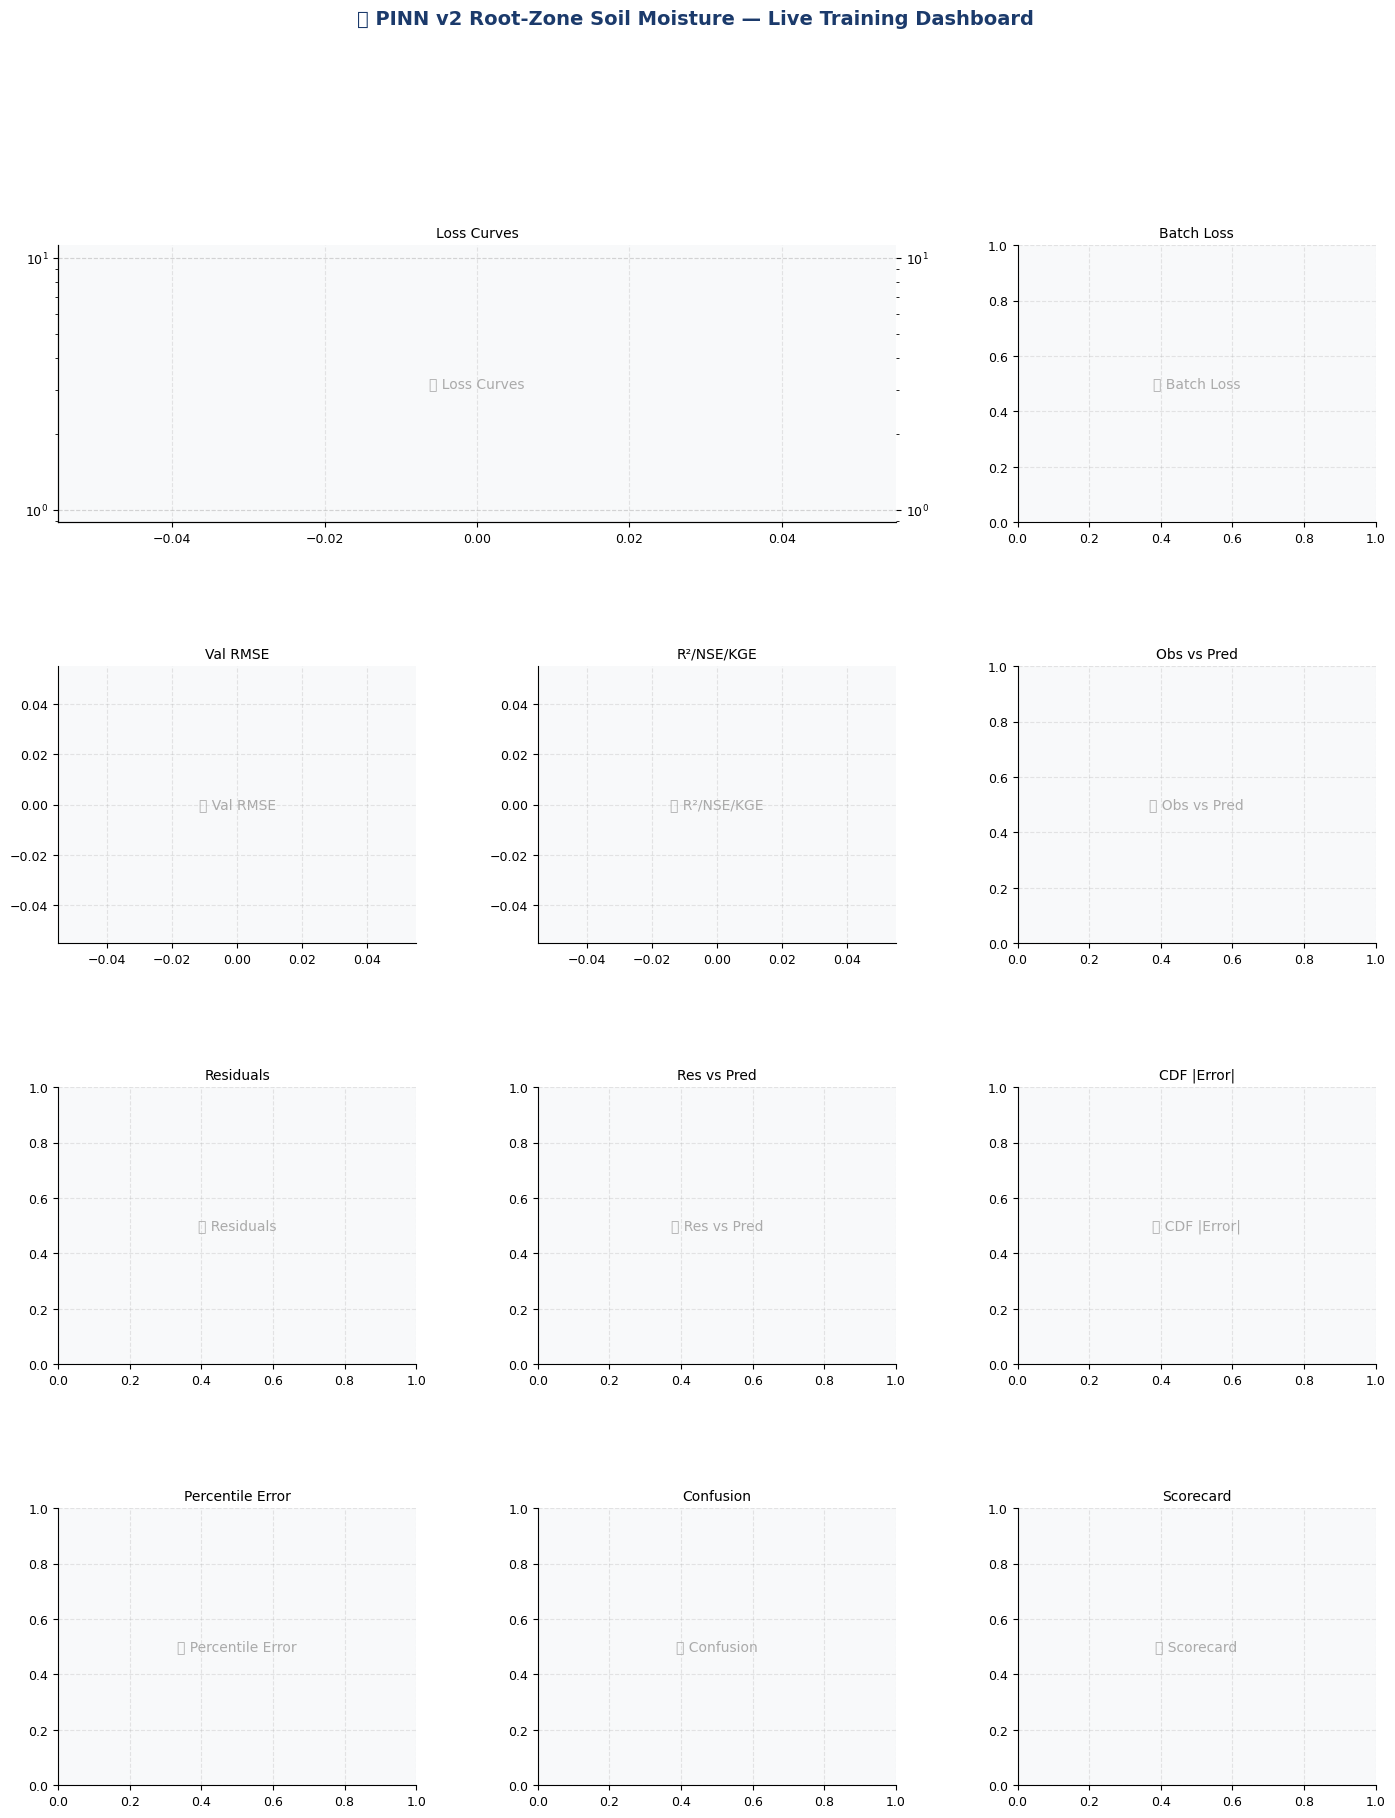

✓ Dashboard ready — run Training cell ▼


In [10]:
# History state
H = dict(epoch=[], phase=[], lr_vals=[],
         loss_total=[], loss_data=[], loss_phys=[], loss_et=[],
         val_rmse=[], val_r2=[], val_nse=[], val_kge=[], val_ep=[],
         batch_idx=[], batch_loss=[])

def nse(y, p):
    return float(1 - np.sum((y-p)**2) / (np.sum((y-y.mean())**2) + EPS))

def kge(y, p):
    r = float(np.corrcoef(y, p)[0, 1])
    a = float(p.std() / (y.std() + EPS))
    b = float(p.mean() / (y.mean() + EPS))
    return 1 - math.sqrt((r-1)**2 + (a-1)**2 + (b-1)**2)

@torch.no_grad()
def validate(loader):
    model.eval()
    ps, ys = [], []
    for Xb, yb in loader:
        ps.append(model(Xb.to(DEVICE)).cpu().numpy())
        ys.append(yb.numpy())
    p = np.concatenate(ps).flatten(); y = np.concatenate(ys).flatten()
    return (float(np.sqrt(mean_squared_error(y, p))),
            float(r2_score(y, p)), nse(y, p), kge(y, p), y, p)

# ── Widgets ──────────────────────────────────────────────────────────────
BADGE_COLORS = {1:'#1B3A6B', 2:'#0D7680', 3:'#1A6B3C', 4:'#C45E00'}
BADGE_LABELS = {1:'Warmup (data only)', 2:'Intro Physics',
                3:'Full Adaptive PINN', 4:'Fine-tune'}
METRIC_KEYS   = ['RMSE', 'R²', 'NSE', 'KGE']
METRIC_TGT    = {'RMSE':0.03, 'R²':0.90, 'NSE':0.90, 'KGE':0.70}
METRIC_HIGHER = {'RMSE':False,'R²':True,'NSE':True,'KGE':True}
w_phase  = widgets.HTML(value='<i>not started</i>')
w_status = widgets.HTML(value='<i>Initialising…</i>')
w_metrics = {k: widgets.HTML() for k in METRIC_KEYS}

def _badge(ph):
    c = BADGE_COLORS.get(ph,'#555'); l = BADGE_LABELS.get(ph,'')
    return (f'<span style="background:{c};color:#fff;padding:4px 12px;'
            f'border-radius:5px;font-weight:bold;font-size:13px">'
            f'Phase {ph} — {l}</span>')

def _metric_card(k, v):
    tgt=METRIC_TGT[k]; hb=METRIC_HIGHER[k]
    ok=(v<=tgt) if not hb else (v>=tgt)
    bg='#d5f5e3' if ok else '#fdebd0'; brd='#1A6B3C' if ok else '#C45E00'
    return (f'<div style="border:2px solid {brd};border-radius:7px;background:{bg};'
            f'padding:7px 16px;text-align:center;min-width:115px;">'
            f'<div style="font-size:11px;color:#555">{k}</div>'
            f'<div style="font-size:22px;font-weight:bold">{v:.4f}</div>'
            f'<div style="font-size:10px">target {tgt} {"✓" if ok else "✗"}</div></div>')

def update_cards(rmse, r2, nse_, kge_):
    for k, v in zip(METRIC_KEYS, [rmse, r2, nse_, kge_]):
        w_metrics[k].value = _metric_card(k, v)

metric_row = widgets.HBox(list(w_metrics.values()),
                           layout=widgets.Layout(gap='10px', margin='6px 0'))

# ── Figure — created ONCE, updated via set_data (10–50× faster than cla) ─
fig = plt.figure(figsize=(17, 20), facecolor='white')
fig.suptitle('🌱 PINN v2 Root-Zone Soil Moisture — Live Training Dashboard',
             fontsize=14, fontweight='bold', color=NAVY, y=0.998)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.34)
ax_loss  = fig.add_subplot(gs[0, :2]); ax_lr = ax_loss.twinx()
ax_batch = fig.add_subplot(gs[0, 2])
ax_rmse  = fig.add_subplot(gs[1, 0]); ax_r2nse = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])
ax_res_hist = fig.add_subplot(gs[2, 0]); ax_res_pred = fig.add_subplot(gs[2, 1])
ax_cdf = fig.add_subplot(gs[2, 2])
ax_pct = fig.add_subplot(gs[3, 0]); ax_cm = fig.add_subplot(gs[3, 1])
ax_sc  = fig.add_subplot(gs[3, 2])

ALL_AXES = [ax_loss, ax_batch, ax_rmse, ax_r2nse, ax_scatter,
            ax_res_hist, ax_res_pred, ax_cdf, ax_pct, ax_cm, ax_sc]

# Pre-create line artists for set_data() pattern — avoids ax.cla() overhead
_lines = {}
for key, col, ls, lw_ in [
    ('loss_total', NAVY,'–',2.0), ('loss_data', TEAL,'–',1.3),
    ('loss_phys', ORANGE,'–',1.3), ('loss_et', GREEN,'–',1.3)]:
    _lines[key], = ax_loss.semilogy([], [], color=col, ls='-', lw=lw_, label=key)
_lines['lr'], = ax_lr.semilogy([], [], color=GOLD, lw=0.9, ls='-.', alpha=0.7)
_lines['rmse'], = ax_rmse.plot([], [], color=NAVY, lw=2)
_lines['r2'],   = ax_r2nse.plot([], [], color=TEAL, lw=2, label='R²')
_lines['nse'],  = ax_r2nse.plot([], [], color=ORANGE, lw=2, label='NSE')
_lines['kge'],  = ax_r2nse.plot([], [], color=GREEN, lw=1.4, ls='--', label='KGE')

for ax, ttl in zip(ALL_AXES,
    ['Loss Curves','Batch Loss','Val RMSE','R²/NSE/KGE','Obs vs Pred',
     'Residuals','Res vs Pred','CDF |Error|','Percentile Error','Confusion','Scorecard']):
    ax.text(0.5,0.5,f'⏳ {ttl}',ha='center',va='center',
            transform=ax.transAxes, fontsize=10, color='#AAA')
    ax.set_title(ttl, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.998])

# ── Redraw: uses set_data() for pre-created lines; cla() only for complex plots ─
def redraw(val_y=None, val_p=None):
    ep = H['epoch']; ve = H['val_ep']
    if ep:
        for key in ['loss_total','loss_data','loss_phys','loss_et']:
            if H[key]: _lines[key].set_data(ep, H[key])
        if H['lr_vals']: _lines['lr'].set_data(ep[:len(H['lr_vals'])], H['lr_vals'])
        ax_loss.relim(); ax_loss.autoscale_view()
        ax_lr.relim();   ax_lr.autoscale_view()

    if H['val_rmse']:
        _lines['rmse'].set_data(ve, H['val_rmse']); ax_rmse.relim(); ax_rmse.autoscale_view()
        _lines['r2'].set_data(ve[:len(H['val_r2'])], H['val_r2'])
        _lines['nse'].set_data(ve[:len(H['val_nse'])], H['val_nse'])
        _lines['kge'].set_data(ve[:len(H['val_kge'])], H['val_kge'])
        ax_r2nse.relim(); ax_r2nse.autoscale_view()

    bl = H['batch_loss'][-80:]
    if bl:
        ax_batch.cla()  # bar chart needs cla — unavoidable
        med = float(np.median(bl))
        colors_b = [RED if v > med*2 else TEAL for v in bl]
        ax_batch.bar(range(len(bl)), bl, color=colors_b, width=1.0, alpha=0.85)
        ax_batch.axhline(float(np.mean(bl)), color=NAVY, lw=1.5, ls='--')
        ax_batch.set_title('Batch Loss (last 80)', fontsize=10)

    if val_y is not None and val_p is not None:
        res = val_y - val_p; ae = np.abs(res)
        for ax in [ax_scatter, ax_res_hist, ax_res_pred, ax_cdf, ax_pct, ax_cm, ax_sc]:
            ax.cla()

        h2d,xe,ye = np.histogram2d(val_y, val_p, bins=50)
        ax_scatter.imshow(np.log1p(h2d).T, origin='lower',
                          extent=[xe[0],xe[-1],ye[0],ye[-1]], aspect='auto', cmap='YlOrRd')
        lo_=min(val_y.min(),val_p.min())-.005; hi_=max(val_y.max(),val_p.max())+.005
        ax_scatter.plot([lo_,hi_],[lo_,hi_],NAVY,lw=1.8,ls='--')
        ax_scatter.text(0.97,0.03,
                        f'RMSE={float(np.sqrt(mean_squared_error(val_y,val_p))):.4f}\n'
                        f'R²={float(r2_score(val_y,val_p)):.4f}',
                        transform=ax_scatter.transAxes, ha='right', va='bottom',
                        fontsize=8, family='monospace',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=NAVY, alpha=0.9))
        ax_scatter.set_title('Obs vs Pred (Val)', fontsize=10)

        bins_r=np.linspace(res.min(),res.max(),50)
        ax_res_hist.hist(res,bins=bins_r,color=TEAL,edgecolor='white',lw=0.3,alpha=0.85)
        ax_res_hist.axvline(0,color=NAVY,lw=2,ls='--')
        ax_res_hist.axvline(res.mean(),color=ORANGE,lw=1.6,label=f'μ={res.mean():.4f}')
        ax_res_hist.set_title('Residual Distribution', fontsize=10)
        ax_res_hist.legend(fontsize=7)

        se_=np.sort(ae); cdf_=np.arange(1,len(se_)+1)/len(se_)*100
        ax_cdf.plot(se_,cdf_,NAVY,lw=2)
        ax_cdf.axvline(0.03,color=RED,lw=1.5,ls='--',label='0.03 target')
        pct03=(ae<=0.03).mean()*100
        ax_cdf.text(0.032,max(pct03-8,5),f'{pct03:.1f}%',color=RED,fontsize=8)
        ax_cdf.set_xlim(0); ax_cdf.set_ylim(0,103)
        ax_cdf.set_title('CDF of |Error|', fontsize=10); ax_cdf.legend(fontsize=7)

        if H['val_rmse']:
            cur_=[H['val_rmse'][-1],H['val_r2'][-1],H['val_nse'][-1],H['val_kge'][-1]]
            tgts_=[0.03,0.90,0.90,0.70]; hb_=[False,True,True,True]
            cols_=[GREEN if ((v<=t) if not h else (v>=t)) else RED
                   for v,t,h in zip(cur_,tgts_,hb_)]
            ax_sc.barh(METRIC_KEYS,cur_,color=cols_,alpha=0.85)
            ax_sc.set_title('Live Scorecard', fontsize=10)

    fig.canvas.draw_idle()
    fig.canvas.flush_events()

display(widgets.VBox([w_phase, w_status, metric_row]))
plt.show()
print('✓ Dashboard ready — run Training cell ▼')


## 🚀 Training (AMP + Temporal Split)

In [11]:
optimizer = optim.Adam(model.parameters(), lr=CFG['lr'],
                       betas=(0.9, 0.999), weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=CFG['lr_factor'],
    patience=CFG['lr_patience'], cooldown=CFG['lr_cooldown'],
    min_lr=CFG['lr_min'], threshold=CFG['lr_threshold'], threshold_mode='rel')

# AMP: 1.5–2× speedup on RTX GPUs with negligible accuracy loss
amp_enabled = (DEVICE == 'cuda')
scaler_amp  = GradScaler(enabled=amp_enabled)

prev_ph = 0
best_rmse, best_state = float('inf'), None
PH_COL = {1:'#D6EAF8', 2:'#D5F5E3', 3:'#FDEBD0', 4:'#EBD9F7'}
t0 = time.time()
_last_val_y = _last_val_p = None

epoch_bar = trange(CFG['total_epochs'], desc='Epochs',
                   bar_format='{l_bar}{bar:30}{r_bar}', colour='blue')

for epoch in epoch_bar:
    phase = get_phase(epoch)
    if phase != prev_ph:
        prev_ph = phase
        w_phase.value = _badge(phase)

    model.train()
    ep_tot = ep_d = ep_p = ep_et = 0.
    n_bat  = len(tr_loader)

    batch_bar = tqdm(tr_loader, desc='  Batches', leave=False,
                     bar_format='{l_bar}{bar:20}{r_bar}', colour='cyan')

    for bidx, (Xb, yb) in enumerate(batch_bar):
        Xb, yb = Xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)  # faster than zero_grad()

        use_phys = phase in (2, 3)
        with autocast(enabled=amp_enabled):
            loss, comp = compute_loss(model, Xb, yb, phase, use_phys)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler_amp.step(optimizer)
        scaler_amp.update()

        bl = float(loss.item())
        H['batch_loss'].append(bl)
        ep_tot += bl; ep_d += comp['data']; ep_p += comp['phys']; ep_et += comp['et']
        batch_bar.set_postfix(loss=f'{bl:.5f}', ph=phase)

        if bidx % CFG['log_every_batch'] == 0:
            redraw(_last_val_y, _last_val_p)

    nb_ = max(n_bat, 1)
    H['epoch'].append(epoch); H['phase'].append(phase)
    H['loss_total'].append(ep_tot/nb_); H['loss_data'].append(ep_d/nb_)
    H['loss_phys'].append(ep_p/nb_);   H['loss_et'].append(ep_et/nb_)

    do_val = (epoch % CFG['log_every_epoch'] == 0 or epoch == CFG['total_epochs']-1)
    if do_val:
        rm_,r2_,ns_,kg_,val_y_,val_p_ = validate(vl_loader)
        _last_val_y, _last_val_p = val_y_, val_p_
        H['val_rmse'].append(rm_); H['val_r2'].append(r2_)
        H['val_nse'].append(ns_);  H['val_kge'].append(kg_)
        H['val_ep'].append(epoch)
        scheduler.step(rm_)
        if rm_ < best_rmse:
            best_rmse = rm_
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        update_cards(rm_, r2_, ns_, kg_)
        current_lr = optimizer.param_groups[0]['lr']
        H['lr_vals'].append(current_lr)
        elapsed = (time.time()-t0)/60
        w_status.value = (
            f'<span style="font-family:monospace;font-size:12px">'
            f'Epoch {epoch:>5} | Ph{phase} | Loss {ep_tot/nb_:.5f} | '
            f'LR {current_lr:.2e} | RMSE <b>{rm_:.4f}</b> R² <b>{r2_:.4f}</b> '
            f'NSE <b>{ns_:.4f}</b> KGE <b>{kg_:.4f}</b> | '
            f'⏱ {elapsed:.1f} min | best {best_rmse:.4f}</span>')
        epoch_bar.set_postfix(RMSE=f'{rm_:.4f}', R2=f'{r2_:.4f}',
                              lr=f'{current_lr:.2e}', ph=phase)
        redraw(_last_val_y, _last_val_p)
    else:
        H['lr_vals'].append(optimizer.param_groups[0]['lr'])

print(f'\n✓ Training complete!  Best val RMSE = {best_rmse:.5f} m³/m³')
if DEVICE == 'cuda':
    print(f'  Peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')
    torch.cuda.empty_cache()


Epochs:   0%|                              | 0/250 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]

...

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/7 [00:00<?, ?it/s]


✓ Training complete!  Best val RMSE = 0.03114 m³/m³
  Peak GPU memory: 0.14 GB


## 📋 Final Evaluation

In [12]:
if best_state:
    model.load_state_dict(best_state)
    print(f'✓ Restored best checkpoint  (val RMSE = {best_rmse:.5f})')

results = {}
for sname, loader_ in [('Validation', vl_loader), ('Test', te_loader)]:
    rm_,r2_,ns_,kg_,yt_,yp_ = validate(loader_)
    pr_  = float(pearsonr(yt_, yp_)[0])
    mae_ = float(mean_absolute_error(yt_, yp_))
    bi_  = (yp_.mean()-yt_.mean()) / (yt_.mean()+EPS) * 100
    ub_  = float(np.sqrt(np.mean(((yp_-yp_.mean())-(yt_-yt_.mean()))**2)))
    results[sname] = dict(RMSE=rm_,MAE=mae_,R2=r2_,NSE=ns_,
                           Pearson_r=pr_,KGE=kg_,Bias_pct=bi_,ubRMSE=ub_,
                           y_true=yt_,y_pred=yp_)

TGT_F   = dict(RMSE=0.03,R2=0.90,NSE=0.90,Pearson_r=0.94,KGE=0.70,Bias_pct=10.)
HIGHER_ = dict(RMSE=False,MAE=False,R2=True,NSE=True,Pearson_r=True,
               KGE=True,Bias_pct=None,ubRMSE=False)

print('\n' + '═'*70)
print(f"  {'Metric':<14} {'Validation':>12} {'Test':>12} {'Target':>9}  ✓/✗")
print('─'*70)
for k in ['RMSE','MAE','ubRMSE','R2','NSE','Pearson_r','KGE','Bias_pct']:
    vv=results['Validation'][k]; tv=results['Test'][k]
    tg=TGT_F.get(k,float('nan')); hb=HIGHER_[k]
    if math.isnan(tg):    st=''
    elif hb is None:      st='✓' if abs(vv)<=tg and abs(tv)<=tg else '✗'
    elif hb:              st='✓' if vv>=tg and tv>=tg else '✗'
    else:                 st='✓' if vv<=tg and tv<=tg else '✗'
    ts=f'{tg:.3f}' if not math.isnan(tg) else '  —  '
    print(f'  {k:<14} {vv:>12.4f} {tv:>12.4f} {ts:>9}  {st}')
print('═'*70)


✓ Restored best checkpoint  (val RMSE = 0.03114)

══════════════════════════════════════════════════════════════════════
  Metric           Validation         Test    Target  ✓/✗
──────────────────────────────────────────────────────────────────────
  RMSE                 0.0311       0.0352     0.030  ✗
  MAE                  0.0244       0.0274       —    
  ubRMSE               0.0236       0.0268       —    
  R2                   0.9275       0.9032     0.900  ✓
  NSE                  0.9275       0.9032     0.900  ✓
  Pearson_r            0.9832       0.9749     0.940  ✓
  KGE                  0.8742       0.8757     0.700  ✓
  Bias_pct            -6.1229      -5.8287    10.000  ✓
══════════════════════════════════════════════════════════════════════


## 🎲 MC-Dropout Uncertainty Quantification

Computing MC-Dropout uncertainty on test set (30 samples)...
  Mean predictive std:  0.0033 m³/m³
  SMAP retrieval noise: ~0.04 m³/m³
  95% CI coverage:      15.6% (ideal: ~95%)
  Well-calibrated:      ✗ — recalibrate


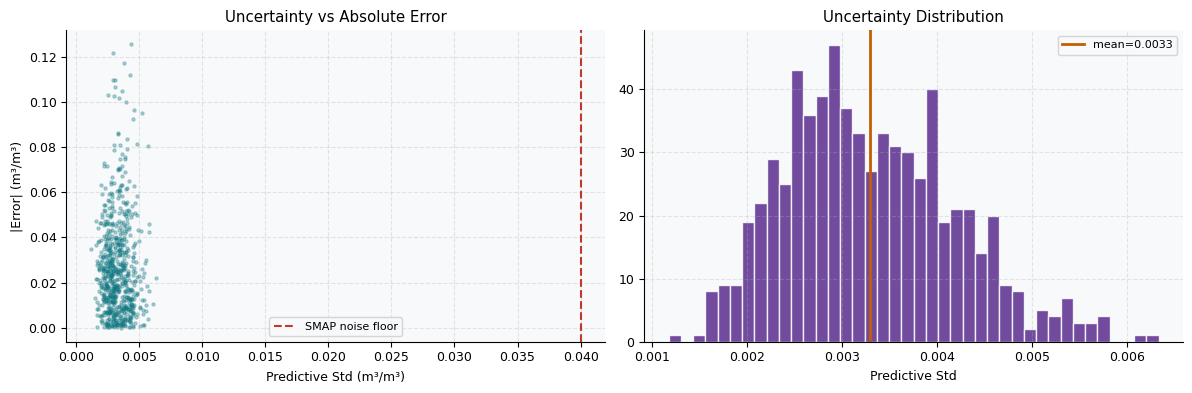

In [13]:
@torch.no_grad()
def mc_predict(loader, n_samples=30):
    """
    Monte Carlo Dropout uncertainty — enables dropout at inference for
    approximate Bayesian uncertainty. n_samples forward passes → mean + std.
    SMAP retrieval error ~0.04 m³/m³; if model std < 0.04 it's well-calibrated.
    """
    model.train()  # enable dropout
    all_preds = []
    for _ in range(n_samples):
        ps = []
        for Xb, _ in loader:
            ps.append(model(Xb.to(DEVICE)).cpu().numpy())
        all_preds.append(np.concatenate(ps).flatten())
    model.eval()
    preds = np.stack(all_preds)  # (n_samples, N)
    return preds.mean(0), preds.std(0)

print('Computing MC-Dropout uncertainty on test set (30 samples)...')
mc_mean, mc_std = mc_predict(te_loader, n_samples=30)
y_te_true = results['Test']['y_true']

# Calibration: check if true values fall within ±1.96 std (95% CI)
within_95 = np.mean(np.abs(y_te_true - mc_mean) <= 1.96 * mc_std) * 100
print(f'  Mean predictive std:  {mc_std.mean():.4f} m³/m³')
print(f'  SMAP retrieval noise: ~0.04 m³/m³')
print(f'  95% CI coverage:      {within_95:.1f}% (ideal: ~95%)')
print(f'  Well-calibrated:      {"✓" if 85 < within_95 < 99 else "✗ — recalibrate"}')

# Plot uncertainty vs error
fig_mc, axes_mc = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')
axes_mc[0].scatter(mc_std, np.abs(y_te_true - mc_mean), alpha=0.3, s=5, color=TEAL)
axes_mc[0].set_xlabel('Predictive Std (m³/m³)')
axes_mc[0].set_ylabel('|Error| (m³/m³)')
axes_mc[0].set_title('Uncertainty vs Absolute Error')
axes_mc[0].axvline(0.04, color=RED, ls='--', label='SMAP noise floor')
axes_mc[0].legend(fontsize=8)
axes_mc[1].hist(mc_std, bins=40, color=PURPLE, edgecolor='white', alpha=0.85)
axes_mc[1].axvline(mc_std.mean(), color=ORANGE, lw=2, label=f'mean={mc_std.mean():.4f}')
axes_mc[1].set_xlabel('Predictive Std'); axes_mc[1].set_title('Uncertainty Distribution')
axes_mc[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 🔲 Binary Confusion Matrix

TP=662, FP=7, TN=14, FN=4
Accuracy=0.984 | Precision=0.990 | Recall=0.994 | F1=0.992


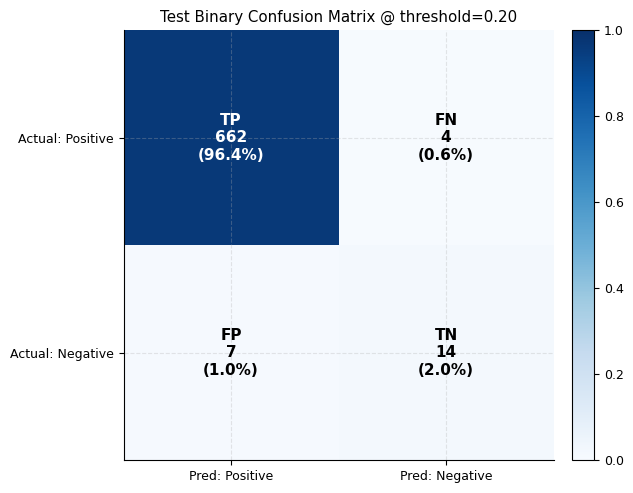

In [14]:
split_name = 'Test'
threshold  = 0.20
y_true = results[split_name]['y_true']
y_pred = results[split_name]['y_pred']
true_pos = y_true >= threshold; pred_pos = y_pred >= threshold
TP=int(np.sum(true_pos & pred_pos)); FP=int(np.sum(~true_pos & pred_pos))
TN=int(np.sum(~true_pos & ~pred_pos)); FN=int(np.sum(true_pos & ~pred_pos))
cm_terms=np.array([[TP,FN],[FP,TN]],dtype=np.int64)
cm_norm=cm_terms/max(cm_terms.sum(),1)
fig_cm,ax_cm=plt.subplots(figsize=(6,5),facecolor='white')
im=ax_cm.imshow(cm_norm,cmap='Blues',vmin=0.0,vmax=1.0)
labels=np.array([['TP','FN'],['FP','TN']])
for i in range(2):
    for j in range(2):
        ax_cm.text(j,i,f'{labels[i,j]}\n{cm_terms[i,j]}\n({cm_norm[i,j]*100:.1f}%)',
                   ha='center',va='center',fontsize=11,
                   color='white' if cm_norm[i,j]>0.5 else 'black',fontweight='bold')
ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(['Pred: Positive','Pred: Negative'])
ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(['Actual: Positive','Actual: Negative'])
ax_cm.set_title(f'{split_name} Binary Confusion Matrix @ threshold={threshold:.2f}')
fig_cm.colorbar(im,ax=ax_cm,fraction=0.046,pad=0.04)
accuracy=( TP+TN)/max(cm_terms.sum(),1)
precision=TP/max(TP+FP,1); recall=TP/max(TP+FN,1)
f1=2*precision*recall/max(precision+recall,1e-12)
print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}')
print(f'Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}')
plt.tight_layout(); plt.show()


## 📈 Final Static Report

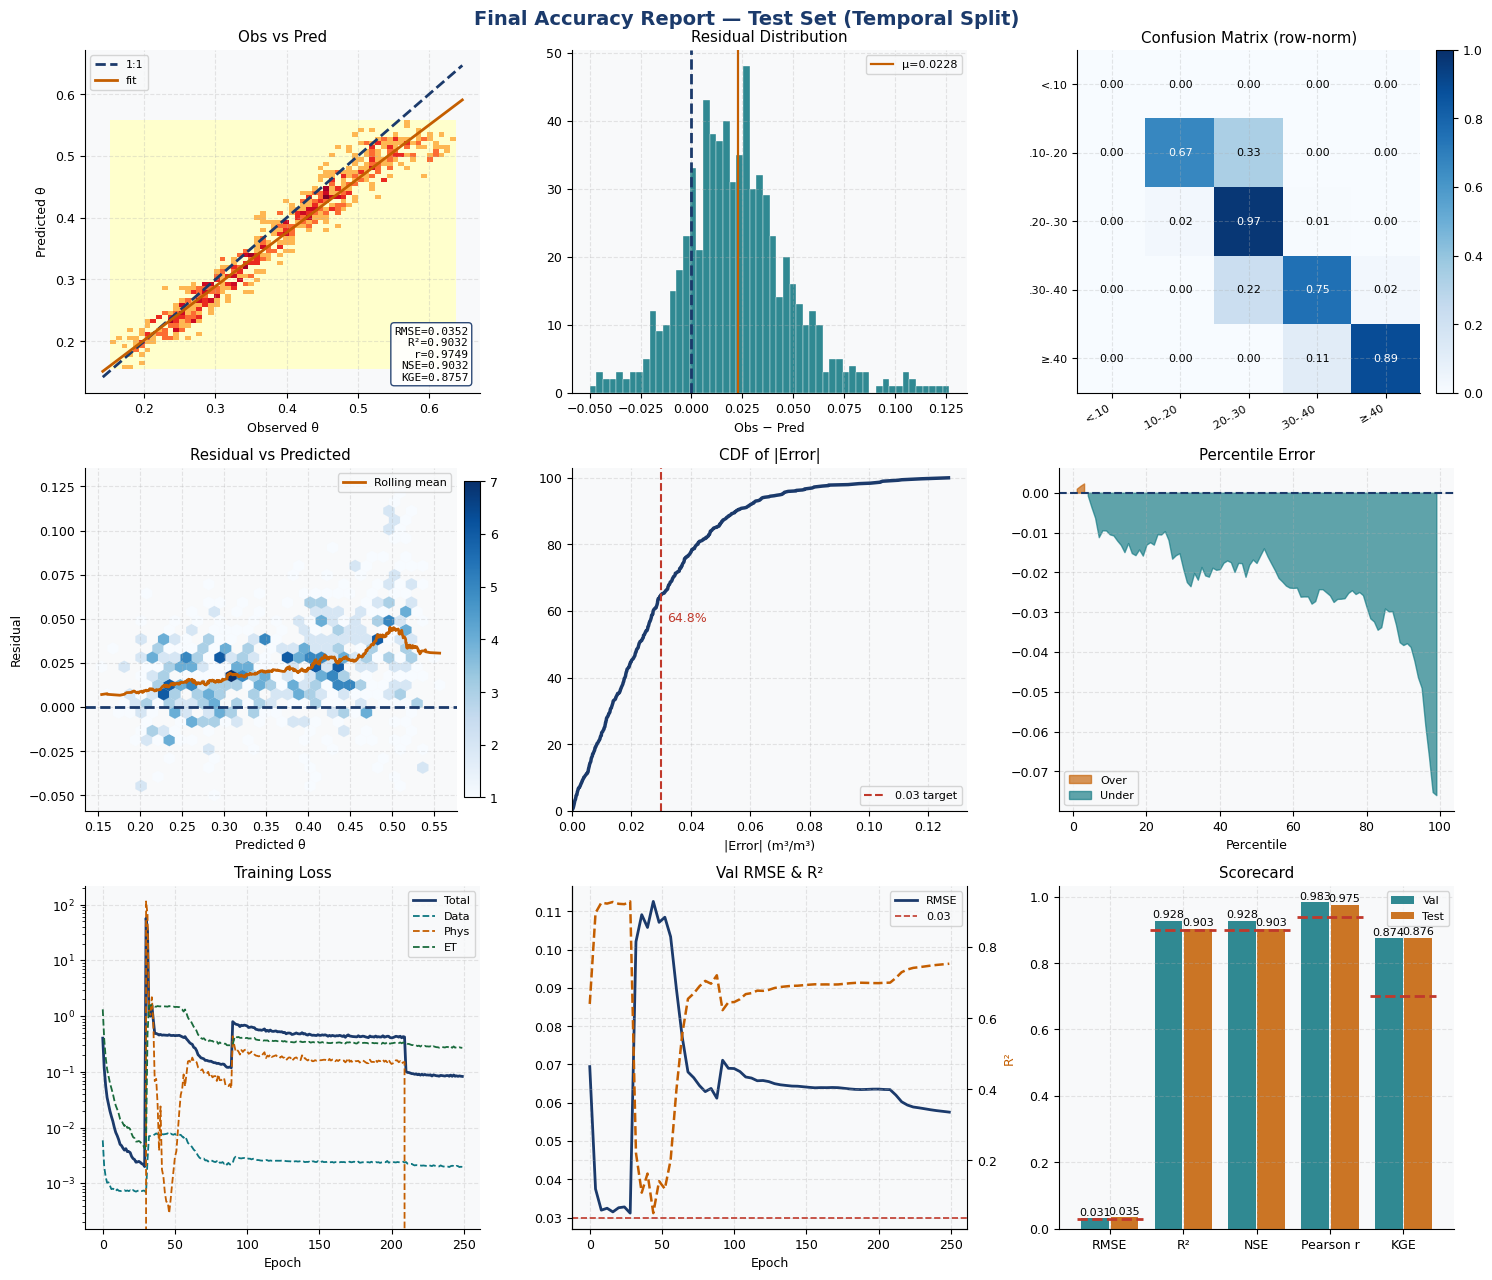

✓ Saved pinn_v2_final_accuracy_report.png


In [15]:
plt.ioff()
yt=results['Test']['y_true']; yp=results['Test']['y_pred']
mv=results['Validation'];     mt=results['Test']
res=yt-yp; ae=np.abs(res)
fig2,ax2=plt.subplots(3,3,figsize=(15,13),facecolor='white')
fig2.suptitle('Final Accuracy Report — Test Set (Temporal Split)',fontsize=14,fontweight='bold',color=NAVY)
a=ax2[0,0]
h2,xe,ye=np.histogram2d(yt,yp,bins=60)
a.imshow(np.log1p(h2).T,origin='lower',extent=[xe[0],xe[-1],ye[0],ye[-1]],aspect='auto',cmap='YlOrRd')
lo_,hi_=min(yt.min(),yp.min())-.01,max(yt.max(),yp.max())+.01
a.plot([lo_,hi_],[lo_,hi_],NAVY,lw=2,ls='--',label='1:1')
m_,b_=np.polyfit(yt,yp,1); xs_=np.linspace(lo_,hi_,80)
a.plot(xs_,m_*xs_+b_,ORANGE,lw=2,label='fit')
a.text(.97,.03,f'RMSE={mt["RMSE"]:.4f}\nR²={mt["R2"]:.4f}\nr={mt["Pearson_r"]:.4f}\nNSE={mt["NSE"]:.4f}\nKGE={mt["KGE"]:.4f}',
       transform=a.transAxes,ha='right',va='bottom',fontsize=8,family='monospace',
       bbox=dict(boxstyle='round,pad=0.3',fc='white',ec=NAVY,alpha=0.92))
a.set_title('Obs vs Pred'); a.set_xlabel('Observed θ'); a.set_ylabel('Predicted θ'); a.legend(fontsize=8)
a=ax2[0,1]
b_=np.linspace(res.min(),res.max(),55)
a.hist(res,bins=b_,color=TEAL,edgecolor='white',lw=0.3,alpha=0.85)
a.axvline(0,color=NAVY,lw=2,ls='--'); a.axvline(res.mean(),color=ORANGE,lw=1.6,label=f'μ={res.mean():.4f}')
a.set_title('Residual Distribution'); a.set_xlabel('Obs − Pred'); a.legend(fontsize=8)
a=ax2[0,2]
bc2=np.array([0,.10,.20,.30,.40,1.]); lbl2=['<.10','.10-.20','.20-.30','.30-.40','≥.40']
yc=np.clip(np.digitize(yt,bc2,right=False)-1,0,4); pc=np.clip(np.digitize(yp,bc2,right=False)-1,0,4)
cm_=confusion_matrix(yc,pc,labels=range(5)); rs_=cm_.sum(1,keepdims=True)
cmn=np.divide(cm_,rs_,out=np.zeros_like(cm_,dtype=float),where=rs_!=0)
im2=a.imshow(cmn,cmap='Blues',vmin=0,vmax=1)
for ii in range(5):
    for jj in range(5):
        a.text(jj,ii,f'{cmn[ii,jj]:.2f}',ha='center',va='center',fontsize=8,color='white' if cmn[ii,jj]>0.5 else 'black')
a.set_xticks(range(5)); a.set_xticklabels(lbl2,rotation=30,ha='right',fontsize=8)
a.set_yticks(range(5)); a.set_yticklabels(lbl2,fontsize=8)
a.set_title('Confusion Matrix (row-norm)'); fig2.colorbar(im2,ax=a,fraction=0.046,pad=0.04)
a=ax2[1,0]
hb2=a.hexbin(yp,res,gridsize=30,cmap='Blues',linewidths=0.1,mincnt=1)
fig2.colorbar(hb2,ax=a,fraction=0.04,pad=0.02); a.axhline(0,color=NAVY,lw=2,ls='--')
si=np.argsort(yp); rl=pd.Series(res[si]).rolling(80,min_periods=1,center=True).mean()
a.plot(yp[si],rl,ORANGE,lw=2,label='Rolling mean')
a.set_title('Residual vs Predicted'); a.set_xlabel('Predicted θ'); a.set_ylabel('Residual'); a.legend(fontsize=8)
a=ax2[1,1]
se3=np.sort(ae); cdf3=np.arange(1,len(se3)+1)/len(se3)*100
a.plot(se3,cdf3,NAVY,lw=2.5); a.axvline(0.03,color=RED,lw=1.5,ls='--',label='0.03 target')
p03=(ae<=0.03).mean()*100; a.text(0.032,max(p03-8,5),f'{p03:.1f}%',color=RED,fontsize=9)
a.set_xlim(0); a.set_ylim(0,103); a.set_title('CDF of |Error|'); a.set_xlabel('|Error| (m³/m³)'); a.legend(fontsize=8)
a=ax2[1,2]
pct3=np.arange(1,100); qe3=np.percentile(yp,pct3)-np.percentile(yt,pct3)
a.fill_between(pct3,qe3,0,where=qe3>=0,alpha=0.65,color=ORANGE,label='Over')
a.fill_between(pct3,qe3,0,where=qe3< 0,alpha=0.65,color=TEAL,  label='Under')
a.axhline(0,color=NAVY,lw=1.5,ls='--'); a.set_title('Percentile Error'); a.set_xlabel('Percentile'); a.legend(fontsize=8)
a=ax2[2,0]
if H['epoch']:
    a.semilogy(H['epoch'],H['loss_total'],NAVY,lw=2,label='Total')
    a.semilogy(H['epoch'],H['loss_data'],TEAL,lw=1.3,ls='--',label='Data')
    a.semilogy(H['epoch'],H['loss_phys'],ORANGE,lw=1.3,ls='--',label='Phys')
    a.semilogy(H['epoch'],H['loss_et'],GREEN,lw=1.3,ls='--',label='ET')
a.set_title('Training Loss'); a.set_xlabel('Epoch'); a.legend(fontsize=8)
a=ax2[2,1]
if H['val_rmse']:
    ve3=H['val_ep'][:len(H['val_rmse'])]
    a.plot(ve3,H['val_rmse'],NAVY,lw=2,label='RMSE')
    ax2b=a.twinx()
    ax2b.plot(H['val_ep'][:len(H['val_r2'])],H['val_r2'],ORANGE,lw=1.8,ls='--',label='R²')
    ax2b.set_ylabel('R²',color=ORANGE); ax2b.spines['right'].set_visible(True)
a.axhline(0.03,color=RED,lw=1.2,ls='--',label='0.03'); a.set_title('Val RMSE & R²'); a.set_xlabel('Epoch'); a.legend(fontsize=8)
a=ax2[2,2]
ks4=['RMSE','R²','NSE','Pearson r','KGE']; ts4=[0.03,0.90,0.90,0.94,0.70]
vc4=[mv['RMSE'],mv['R2'],mv['NSE'],mv['Pearson_r'],mv['KGE']]
tc4=[mt['RMSE'],mt['R2'],mt['NSE'],mt['Pearson_r'],mt['KGE']]
xb4=np.arange(len(ks4))
bv4=a.bar(xb4-.2,vc4,.38,color=TEAL,alpha=.85,label='Val')
bt4=a.bar(xb4+.2,tc4,.38,color=ORANGE,alpha=.85,label='Test')
for i,t_ in enumerate(ts4): a.hlines(t_,xb4[i]-.45,xb4[i]+.45,colors=RED,lw=2,ls='--')
for bar in [*bv4,*bt4]:
    a.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.003,f'{bar.get_height():.3f}',ha='center',va='bottom',fontsize=8)
a.set_xticks(xb4); a.set_xticklabels(ks4,fontsize=9); a.set_title('Scorecard'); a.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pinn_v2_final_accuracy_report.png',dpi=160,bbox_inches='tight')
plt.show(); plt.ion()
print('✓ Saved pinn_v2_final_accuracy_report.png')


## 💾 Save Artefacts

In [16]:
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)

torch.save({'model_state': best_state or model.state_dict(),
            'val_rmse': best_rmse, 'cfg': CFG,
            'feature_names': FEATURE_NAMES, 'fourier_cols': FOURIER_COLS},
           'checkpoints/pinn_v2_best.pt')
print('✓ checkpoints/pinn_v2_best.pt')

pd.DataFrame({k: H[k] for k in
    ['epoch','phase','loss_total','loss_data','loss_phys','loss_et']
}).to_csv('results/training_history.csv', index=False)

for sn, res_ in results.items():
    pd.DataFrame({'y_true': res_['y_true'], 'y_pred': res_['y_pred'],
                  'residual': res_['y_true']-res_['y_pred']}
    ).to_csv(f'results/{sn.lower()}_predictions.csv', index=False)
    print(f'✓ results/{sn.lower()}_predictions.csv')

with open('results/config.json','w') as f:
    json.dump({k:v for k,v in CFG.items() if not callable(v)}, f, indent=2)
print('✓ results/config.json')


✓ checkpoints/pinn_v2_best.pt
✓ results/validation_predictions.csv
✓ results/test_predictions.csv
✓ results/config.json


## 🔭 Single-Row Inference (with Uncertainty)

In [17]:
@torch.no_grad()
def predict(row_dict, n_mc=30):
    """
    Returns point prediction + MC-Dropout uncertainty interval.
    n_mc=1 → deterministic; n_mc>1 → uncertainty quantification.
    """
    x = np.zeros((1, len(FEATURE_NAMES)), dtype=np.float32)
    for col, val in row_dict.items():
        if col in IDX: x[0, IDX[col]] = float(val)
    xs = scaler.transform(x).astype(np.float32)
    for col in PHYS_COLS:
        if col in row_dict: xs[0, IDX[col]] = float(row_dict[col])
    xt = torch.tensor(xs).to(DEVICE)
    if n_mc <= 1:
        model.eval()
        return round(float(model(xt).item()), 5), None
    model.train()   # enable dropout
    preds = [float(model(xt).item()) for _ in range(n_mc)]
    model.eval()
    return round(float(np.mean(preds)), 5), round(float(np.std(preds)), 5)

sample = df_clean.iloc[te_idx[0]]
sd     = {c: sample[c] for c in FEATURE_NAMES if c in sample}
pred, unc = predict(sd, n_mc=30)
true_  = sample[TARGET] if TARGET in sample else 'N/A'
print(f'  True θ      : {true_}')
print(f'  Pred θ      : {pred}  m³/m³')
if unc:
    print(f'  Uncertainty : ±{unc:.5f}  m³/m³  (1σ MC-Dropout)')
    print(f'  95% CI      : [{pred-1.96*unc:.5f}, {pred+1.96*unc:.5f}]')
print(f'  |Error|     : {abs(float(true_)-pred):.5f}  m³/m³')


  True θ      : 0.4424
  Pred θ      : 0.42992  m³/m³
  Uncertainty : ±0.00279  m³/m³  (1σ MC-Dropout)
  95% CI      : [0.42445, 0.43539]
  |Error|     : 0.01248  m³/m³
